In [219]:
from langgraph.graph import StateGraph ,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [220]:
load_dotenv()
model=ChatOpenAI()

In [221]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    iniings: int
    NO: int
    fours: int
    six: int

    sr: float
    avg: float
    bpb: float
    boundary_percent: float

    summary: str


In [222]:
def calculate_sr(state):
    sr = (state["runs"] / state["balls"]) * 100
    return {"sr": round(sr, 2)}

In [223]:
def calculate_avg(state):
    avg = state["runs"] / (state["iniings"] - state["NO"])
    return {"avg": round(avg, 2)}


In [224]:
def calculate_bpb(state):
    bpb = state["balls"] / (state["fours"] + state["six"])
    return {"bpb": round(bpb, 2)}

In [ ]:
def calculate_boundary_percent(state):
    bp = (
        (state["fours"] * 4 + state["six"] * 6)
        * 100
        / state["runs"]
    )

    return {"boundary_percent": round(bp, 2)}


In [226]:
def summary(state):

    text = f"""
Strike Rate: {state['sr']}
Average: {state['avg']}
Balls Per Boundary: {state['bpb']}
Boundary Percentage: {state['boundary_percent']}
"""

    return {"summary": text}

In [227]:
graph=StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_avg',calculate_avg)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('summary',summary)

#edge
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_avg')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_avg','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')

graph.add_edge('summary',END)

workflow=graph.compile()

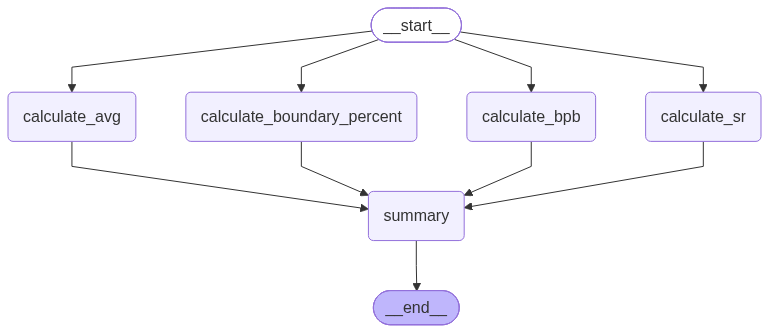

In [228]:
workflow

In [229]:
initial_state = {
    'runs': 210,
    'balls': 80,
    'iniings': 2,
    'NO': 1,
    'fours': 20,
    'six': 10
}

In [230]:
workflow.invoke(initial_state)

{'runs': 210,
 'balls': 80,
 'iniings': 2,
 'NO': 1,
 'fours': 20,
 'six': 10,
 'sr': 262.5,
 'avg': 210.0,
 'bpb': 2.67,
 'boundary_percent': 66.67,
 'summary': '\nStrike Rate: 262.5\nAverage: 210.0\nBalls Per Boundary: 2.67\nBoundary Percentage: 66.67\n'}